# 1. Importing libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Loading the dataset

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


# 3. Data Cleaning


In [3]:
# Some of spam.csv contain unnecessary columns
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]

### Checking for missing and duplicate values

In [ ]:
# Checking for missing and duplicate values
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Values:", df.duplicated().sum())


Missing Values:
 label      0
message    0
dtype: int64

Duplicate Values: 403


In [ ]:
# Removing duplicates if any
df = df.drop_duplicates()
print("\nAfter Removing Duplicates:", df.shape)


After Removing Duplicates: (5169, 2)


### Encoding Labels (ham=0, spam=1)


In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# 5. Exploratory Data Analysis (EDA)


### Bar Plot

C:\Users\user\AppData\Local\Temp\ipykernel_11780\2839767901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


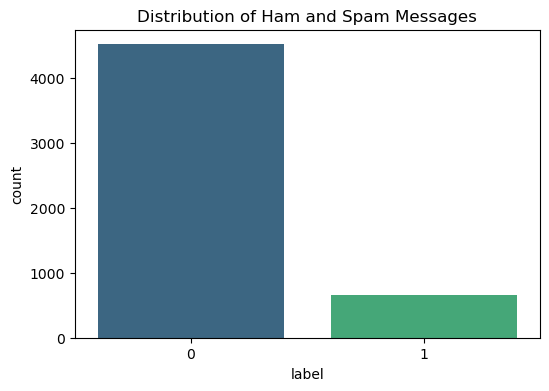

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title("Distribution of Ham and Spam Messages")
plt.show()

### Pie Chart for more detailed spread of data

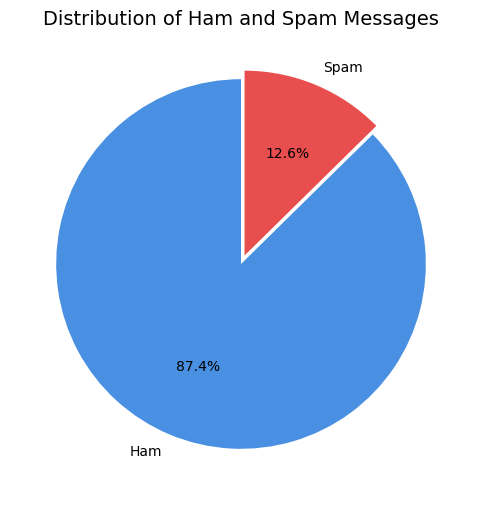

In [ ]:
# Calculating label counts
label_counts = df['label'].value_counts()
labels = ['Ham', 'Spam']
colors = ['#4A90E2', '#E94E4E']  # Blue for Ham, Red for Spam

# Create Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    label_counts,
    labels=labels,
    autopct='%1.1f%%',   # show percentages
    startangle=90,       # rotate start for better orientation
    colors=colors,
    explode=(0, 0.05),   # slightly separate the slice
    shadow=False
)
plt.title("Distribution of Ham and Spam Messages", fontsize=14)
plt.show()


# WordCloud for Messages


### Spam Messages

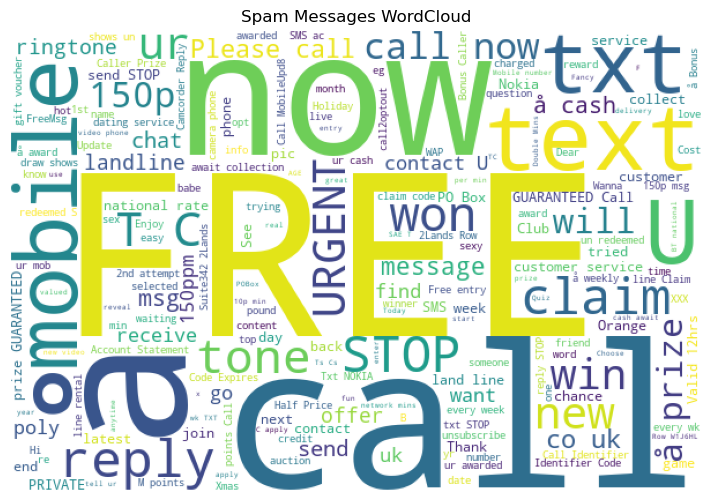

In [ ]:
spam_words = ' '.join(list(df[df['label'] == 1]['message']))
ham_words = ' '.join(list(df[df['label'] == 0]['message']))

plt.figure(figsize=(10,6))
wc_spam = WordCloud(width=600, height=400, background_color='white').generate(spam_words)
plt.imshow(wc_spam)
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()

### Ham Messages

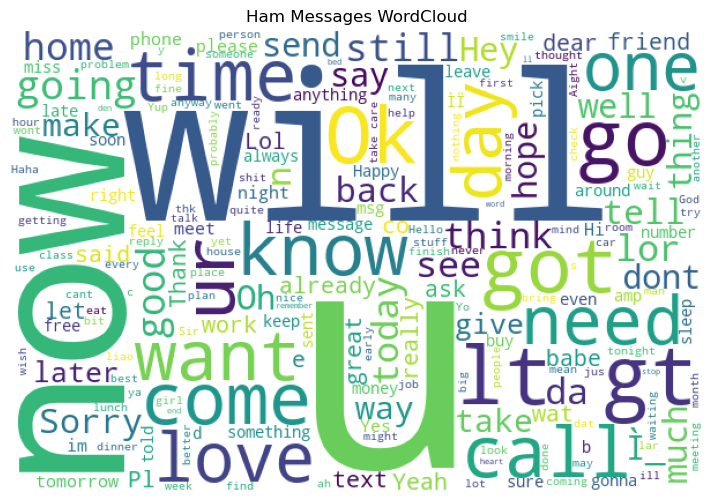

In [12]:
plt.figure(figsize=(10,6))
wc_ham = WordCloud(width=600, height=400, background_color='white').generate(ham_words)
plt.imshow(wc_ham)
plt.axis('off')
plt.title("Ham Messages WordCloud")
plt.show()

# 6. Text Vectorization


In [ ]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])
y = df['label']

# 7. Spliting the Dataset for Training and Testing


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 4135
Testing Samples: 1034


# 8. Model Training using Logistic Regression


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# 9. Prediction & Evaluation


In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [24]:
print("\nModel Accuracy:", round(acc * 100, 2), "%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Model Accuracy: 97.68 %

Confusion Matrix:
 [[888   1]
 [ 23 122]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       0.99      0.84      0.91       145

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



# 10. Extra Visualization for detailed Evaluations


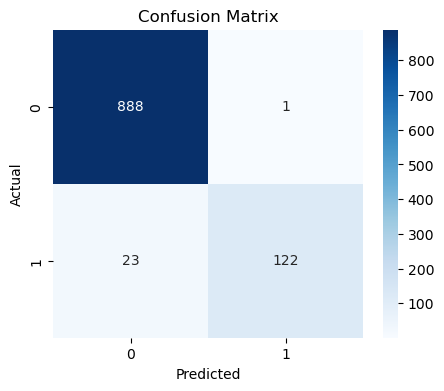

In [32]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Top common Words from Spam Messages

C:\Users\user\AppData\Local\Temp\ipykernel_11780\2031746747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=df_top_spam, palette='Reds_r')


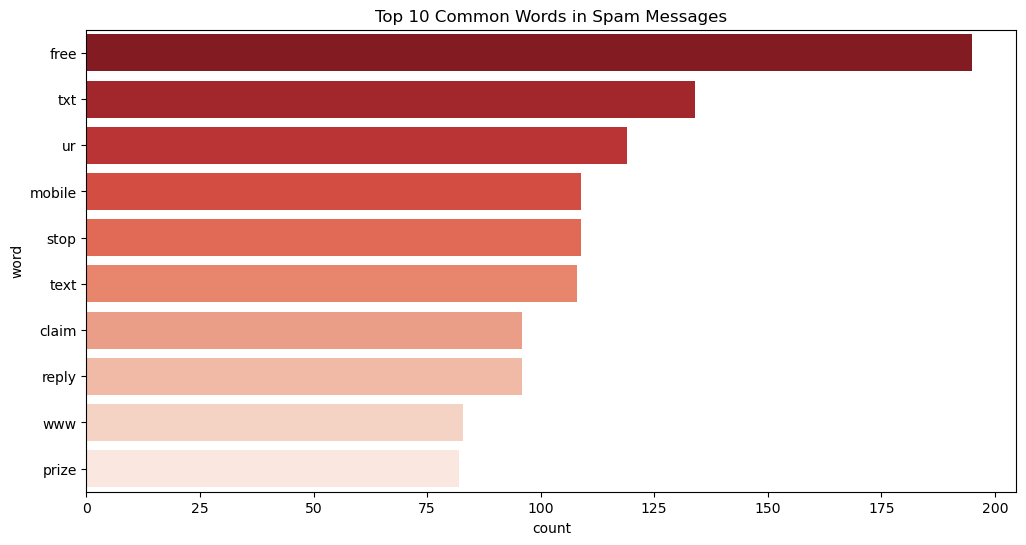

In [35]:
#finding the top 10 common words in spam messages
vectorizer = CountVectorizer(stop_words='english')
X_spam = vectorizer.fit_transform(df[df['label'] == 1]['message'])
sum_words_spam = X_spam.sum(axis=0)
words_freq_spam = [(word, sum_words_spam[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq_spam = sorted(words_freq_spam, key=lambda x: x[1], reverse=True)
top_10_spam = words_freq_spam[:10]
df_top_spam = pd.DataFrame(top_10_spam, columns=['word', 'count'])
plt.figure(figsize=(12,6))
sns.barplot(x='count', y='word', data=df_top_spam, palette='Reds_r')
plt.title("Top 10 Common Words in Spam Messages")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_11780\2089623195.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=df_top_ham, palette='Blues_r')


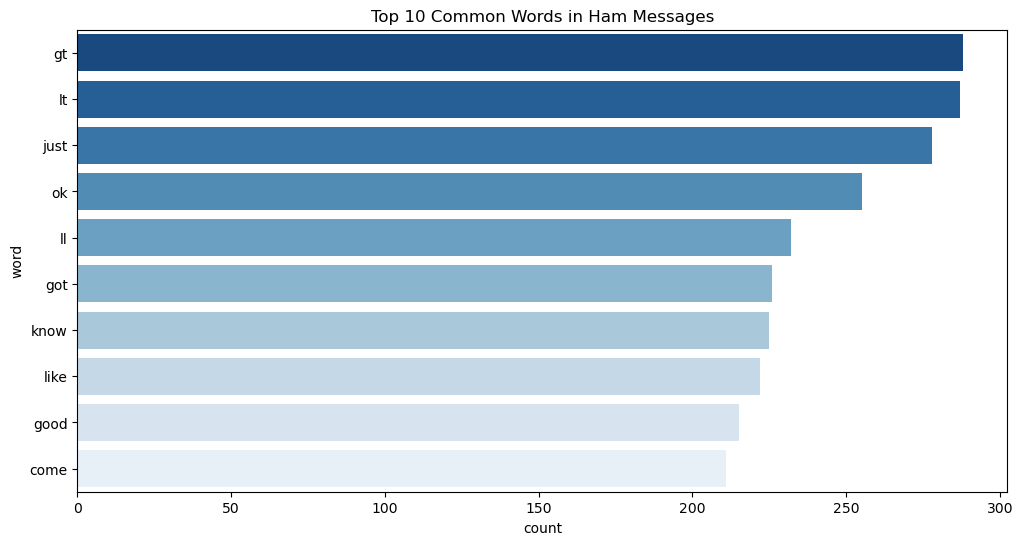

In [36]:
#finding the top 10 common words in ham messages
vectorizer = CountVectorizer(stop_words='english')
X_ham = vectorizer.fit_transform(df[df['label'] == 0]['message'])
sum_words_ham = X_ham.sum(axis=0)
words_freq_ham = [(word, sum_words_ham[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq_ham = sorted(words_freq_ham, key=lambda x: x[1], reverse=True)
top_10_ham = words_freq_ham[:10]
df_top_ham = pd.DataFrame(top_10_ham, columns=['word', 'count'])
plt.figure(figsize=(12,6))
sns.barplot(x='count', y='word', data=df_top_ham, palette='Blues_r')
plt.title("Top 10 Common Words in Ham Messages")
plt.show()


## Distribution of Message Length

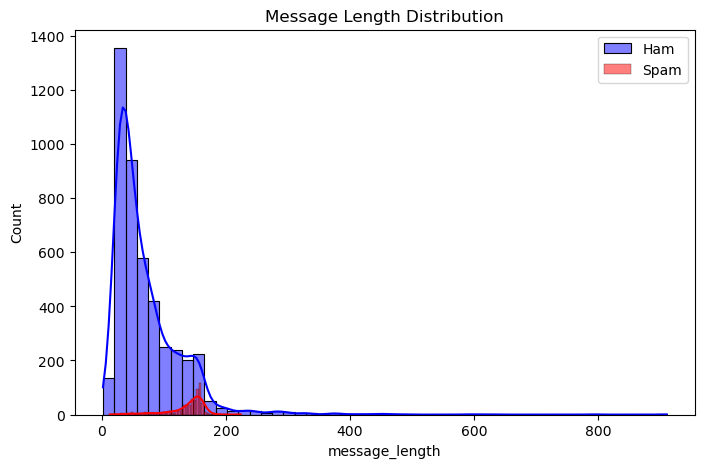

In [33]:
df['message_length'] = df['message'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df[df['label']==0]['message_length'], bins=50, color='blue', label='Ham', kde=True)
sns.histplot(df[df['label']==1]['message_length'], bins=50, color='red', label='Spam', kde=True)
plt.legend()
plt.title("Message Length Distribution")
plt.show()

## Pair plot

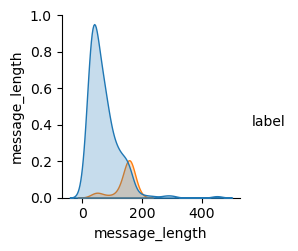

In [34]:
sns.pairplot(df.sample(300), hue='label')
plt.show()